In [1]:
import pandas as pd
import pysam
import os
import json

# assemblies

In [2]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [3]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")

# RepeatMasker

In [13]:
rmDict={}
directory='/LeeLab/HPRC/chromosomeY/Data/RepeatMasker/'
for file in os.listdir(directory):
    rmDict[file.split(".")[0]]=directory+file

## Read in MSA

In [5]:
from __future__ import annotations

from pathlib import Path
from typing import Union, List, Dict
import pandas as pd


def msa_fasta_to_df(
    fasta_path: Union[str, Path],
    *,
    long: bool = False,
    keep_gaps: bool = True,
    fill_value: str = "-",
) -> pd.DataFrame:
    """
    Read a multi-sequence alignment FASTA and convert to a pandas DataFrame.

    Parameters
    ----------
    fasta_path : str | Path
        Path to an MSA FASTA file.
    long : bool
        If False (default): return wide matrix with index=sequence IDs and columns=positions (1..L).
        If True: return long/tidy table with columns: id, pos, base.
    keep_gaps : bool
        If True, keep '-' gap characters as-is. If False, convert '-' to NaN.
    fill_value : str
        When sequences are different lengths, pad shorter ones to max length with this value.
        For an MSA this should rarely be needed, but it makes the function robust.

    Returns
    -------
    pd.DataFrame
    """
    fasta_path = Path(fasta_path)
    if not fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {fasta_path}")

    seqs: Dict[str, str] = {}
    cur_id = None
    cur_chunks: List[str] = []

    def _commit():
        nonlocal cur_id, cur_chunks
        if cur_id is None:
            return
        seq = "".join(cur_chunks).strip()
        if not seq:
            raise ValueError(f"Empty sequence for record '{cur_id}' in {fasta_path}")
        if cur_id in seqs:
            raise ValueError(f"Duplicate FASTA header/id '{cur_id}' in {fasta_path}")
        seqs[cur_id] = seq
        cur_id, cur_chunks = None, []

    with fasta_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                _commit()
                cur_id = line[1:].split()[0]
                cur_chunks = []
            else:
                if cur_id is None:
                    raise ValueError("FASTA parse error: sequence line before any header ('>').")
                cur_chunks.append(line)

    _commit()

    if not seqs:
        raise ValueError(f"No sequences found in {fasta_path}")

    max_len = max(len(s) for s in seqs.values())
    ids = list(seqs.keys())
    mat = []
    for i in ids:
        s = seqs[i]
        if len(s) < max_len:
            s = s + (fill_value * (max_len - len(s)))
        elif len(s) > max_len:
            s = s[:max_len]
        mat.append(list(s))

    wide = pd.DataFrame(mat, index=ids, columns=pd.RangeIndex(1, max_len + 1, name="pos"))
    wide.index.name = "id"

    if not keep_gaps:
        wide = wide.replace("-", pd.NA)

    if not long:
        return wide

    long_df = (
        wide.reset_index()
            .melt(id_vars="id", var_name="pos", value_name="base")
            .sort_values(["id", "pos"], kind="stable")
            .reset_index(drop=True)
    )
    if not keep_gaps:
        long_df.loc[long_df["base"] == "-", "base"] = pd.NA
    return long_df


In [6]:
import re
from typing import List, Tuple

def pair_front_back_different_samples(row_names: List[str]) -> List[Tuple[str, str]]:
    """
    Return (front_row, back_row) pairs where:
      - front/back suffix is determined by the final '_' token (case-insensitive)
      - sample name is everything before ':' (e.g., 'NA19331' from 'NA19331_chrY:...')
      - the samples are different (e.g., NA19331 front can pair with HG01074 back)
    """
    front_rows = [] 
    back_rows  = []  

    suffix_re = re.compile(r"_([^_]+)$")  

    for r in row_names:
        if ":" not in r:
            continue
        sample = r.split(":", 1)[0].strip()

        m = suffix_re.search(r)
        if not m:
            continue
        suffix = m.group(1).strip().lower()

        if suffix == "front":
            front_rows.append((sample, r))
        elif suffix == "back":
            back_rows.append((sample, r))

    pairs: List[Tuple[str, str]] = []
    for s_front, r_front in front_rows:
        for s_back, r_back in back_rows:
            if s_front != s_back:  
                pairs.append((r_front, r_back))

    return pairs

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_front_back_quadrants(df,
                             sample_col="Sample",
                             x_col="Coordinate",
                             y_col="Hit",
                             hue_col="MatchType",
                             point_size=5,
                             alpha=0.6,
                             vlines=None, outFile=None):
    """
    vlines (Option B):
      - dict keyed by (SampleName, Side) -> list of x positions
      - OR dict keyed by SampleName -> list of x positions (applies to both sides)
      - If not a dict, treated as a list applied to all panels
    """

    d = df.copy()

    d["SampleName"] = d[sample_col].str.split(":").str[0]

    d["Side"] = d[sample_col].str.extract(r"_(Front|Back)$", expand=False)

    bounds = d[sample_col].str.extract(r":(\d+)-(\d+)_", expand=True)
    d["Xmin"] = pd.to_numeric(bounds[0], errors="coerce")
    d["Xmax"] = pd.to_numeric(bounds[1], errors="coerce")

    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")

    d = d.dropna(subset=["SampleName", "Side", "Xmin", "Xmax", x_col, y_col, hue_col])

    agg = (
        d.groupby(["SampleName", "Side", x_col, hue_col], as_index=False)[y_col]
         .sum()
    )

    limits = (
        d.groupby(["SampleName", "Side"], as_index=False)
         .agg(xmin=("Xmin", "min"), xmax=("Xmax", "max"))
    )

    samples = sorted(agg["SampleName"].unique())
    sides = ["Front", "Back"]
    matchtypes = sorted(agg[hue_col].unique())

    fig, axes = plt.subplots(
        len(samples), 2,
        figsize=(12, max(3.0, 3.0 * len(samples))),
        sharey=True,
        squeeze=False,
        constrained_layout=True
    )

    for i, sname in enumerate(samples):
        for j, side in enumerate(sides):
            ax = axes[i, j]

            sub = agg[(agg["SampleName"] == sname) & (agg["Side"] == side)]
            lim = limits[(limits["SampleName"] == sname) & (limits["Side"] == side)]

            if sub.empty or lim.empty:
                ax.set_title(f"{sname} | {side} (no data)")
                ax.set_axis_off()
                continue

            xmin, xmax = int(lim["xmin"].iloc[0])-1000, int(lim["xmax"].iloc[0])+1000

            # points by MatchType
            for mt in matchtypes:
                ssub = sub[sub[hue_col] == mt]
                if ssub.empty:
                    continue
                ax.scatter(
                    ssub[x_col].astype(int).values,
                    ssub[y_col].values,
                    s=point_size,
                    alpha=alpha,
                    label=str(mt),
                    c=str(mt)  
                )

            if isinstance(vlines, dict):
                xs = vlines.get((sname, side), vlines.get(sname, []))
            else:
                xs = vlines or []

            for x in xs:
                ax.axvline(int(x), linestyle="--", linewidth=1, alpha=0.7, color='green')

            ax.set_xlim(xmin, xmax)
            ax.set_xlabel("Coordinate")
            if j == 0:
                ax.set_ylabel("Count")
            ax.set_title(f"{sname} | {side}")

    #legend
    #handles, labels = axes[0, 0].get_legend_handles_labels()
    #if handles:
    #    fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 6), frameon=False)

    if outFile:
        plt.savefig(outFile, dpi=300)
    plt.show()

In [8]:
import numpy as np
import pandas as pd

def add_breakpoint_windows(
    df: pd.DataFrame,
    group_cols=("Sample", "Side"),
    start_col="Start",
    end_col="End",
    snpcount_col="SNPCount",
    windowsize_col="WindowSize",
    snptype_col="SNPtype",
    breakpoint_label="BREAKPOINT_WINDOW",
) -> pd.DataFrame:
    """
    For each (Sample, Side) group, sort by Start and insert "BREAKPOINT_WINDOW"
    rows for any gaps between consecutive intervals.

    Notes:
      - Gap row coordinates are: Start = prev_end + 1, end = next_start - 1
      - WindowSize is computed like your example: end - Start (single base => 0)
      - SNPCount is set to NaN for inserted rows
      - If intervals overlap or touch (next_start <= prev_end + 1), no row is added
    """
    required = set(group_cols) | {start_col, end_col, snptype_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    out_chunks = []
    work = df.copy()
    work[start_col] = pd.to_numeric(work[start_col], errors="raise")
    work[end_col] = pd.to_numeric(work[end_col], errors="raise")

    cols = list(work.columns)

    for _, g in work.groupby(list(group_cols), sort=False):
        g = g.sort_values(start_col, kind="mergesort").reset_index(drop=True)

        rows = []
        for i in range(len(g)):
            cur = g.iloc[i]
            rows.append(cur.to_dict())

            if i == len(g) - 1:
                continue

            prev_end = int(cur[end_col])
            next_start = int(g.iloc[i + 1][start_col])

            gap_start = prev_end + 1
            gap_end = next_start - 1

            if gap_end >= gap_start:  
                new_row = {c: np.nan for c in cols}
                for c in group_cols:
                    new_row[c] = cur[c]
                new_row[start_col] = gap_start
                new_row[end_col] = gap_end
                if windowsize_col in cols:
                    new_row[windowsize_col] = gap_end - gap_start  
                if snpcount_col in cols:
                    new_row[snpcount_col] = np.nan
                new_row[snptype_col] = breakpoint_label
                rows.append(new_row)

        out_chunks.append(pd.DataFrame(rows, columns=cols))

    out = pd.concat(out_chunks, ignore_index=True)

    if windowsize_col in out.columns:
        out[windowsize_col] = pd.to_numeric(out[end_col]) - pd.to_numeric(out[start_col])

    return out


HG02492_HG01167_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


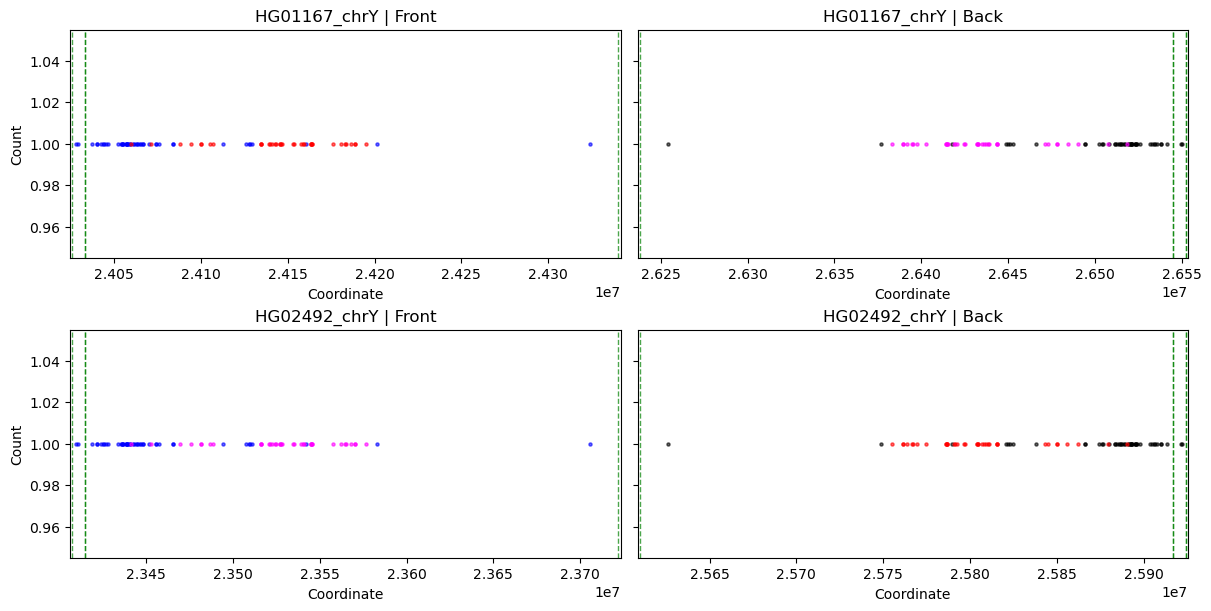

HG02071_HG00706_T2TvsGRCh38_Redbreakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


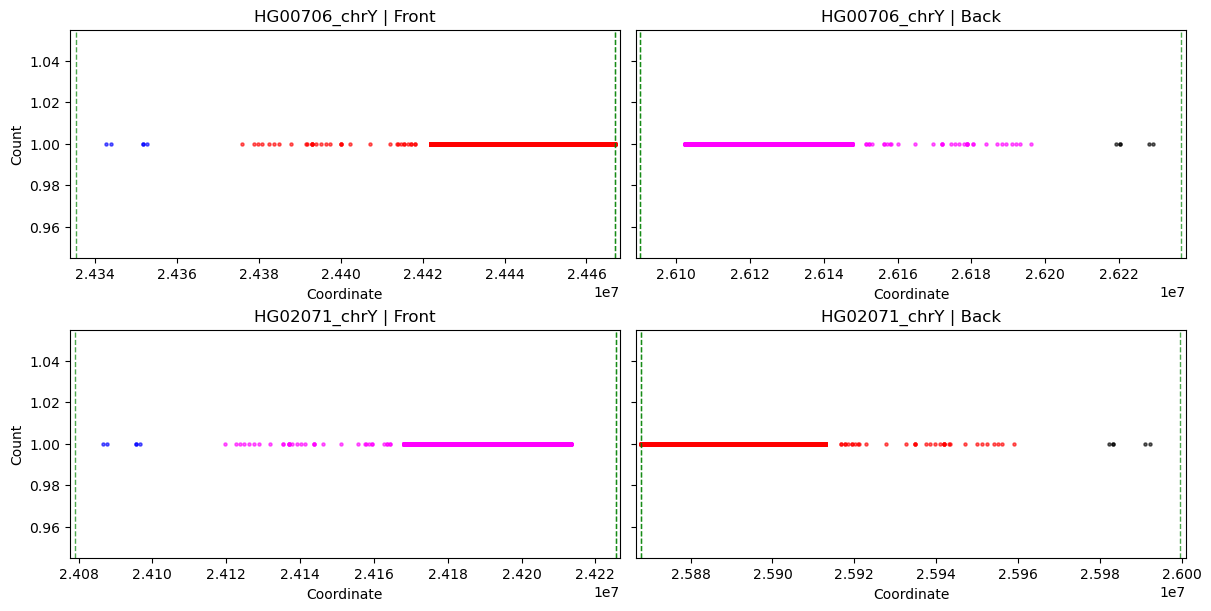

HG02027_HG02392_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


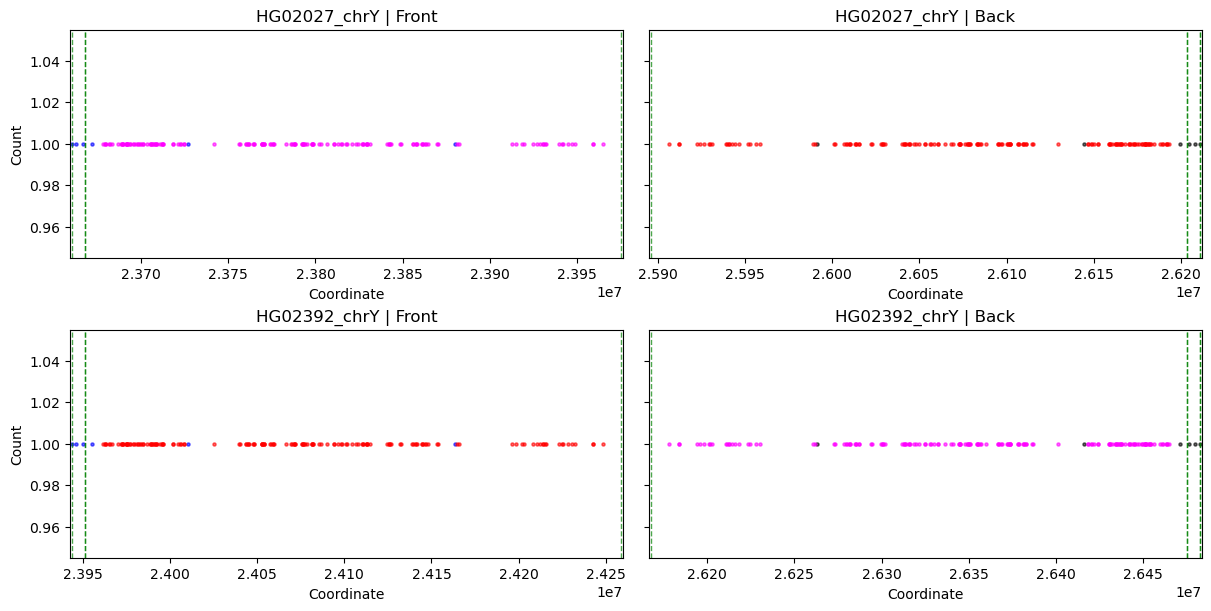

HG02717_HG03471_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


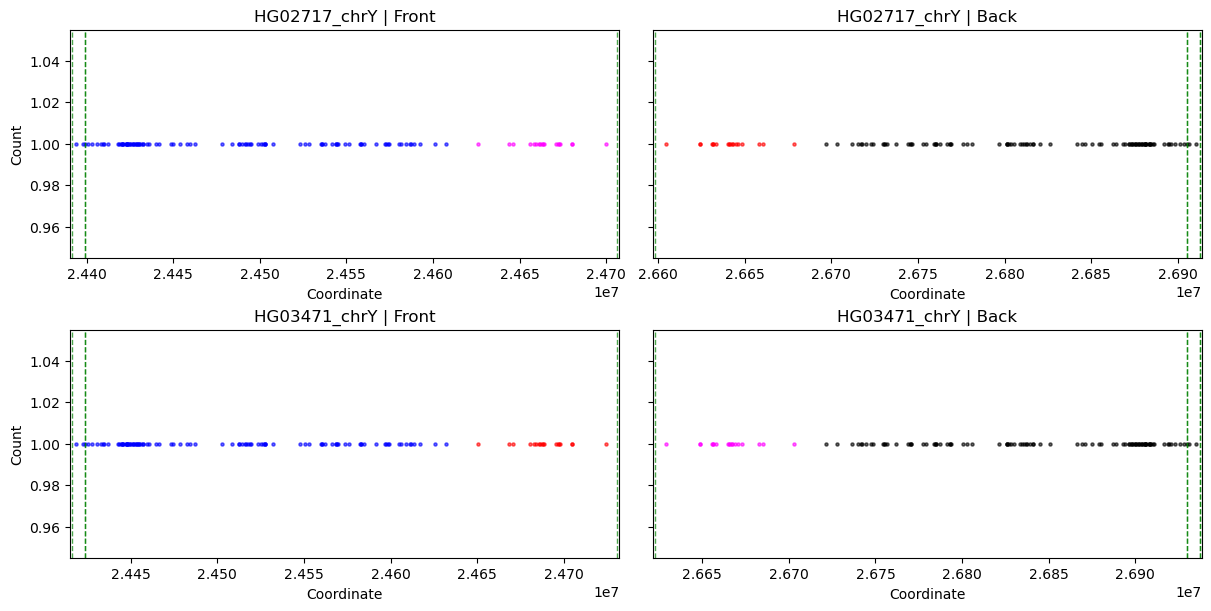

HG002_HG01167_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


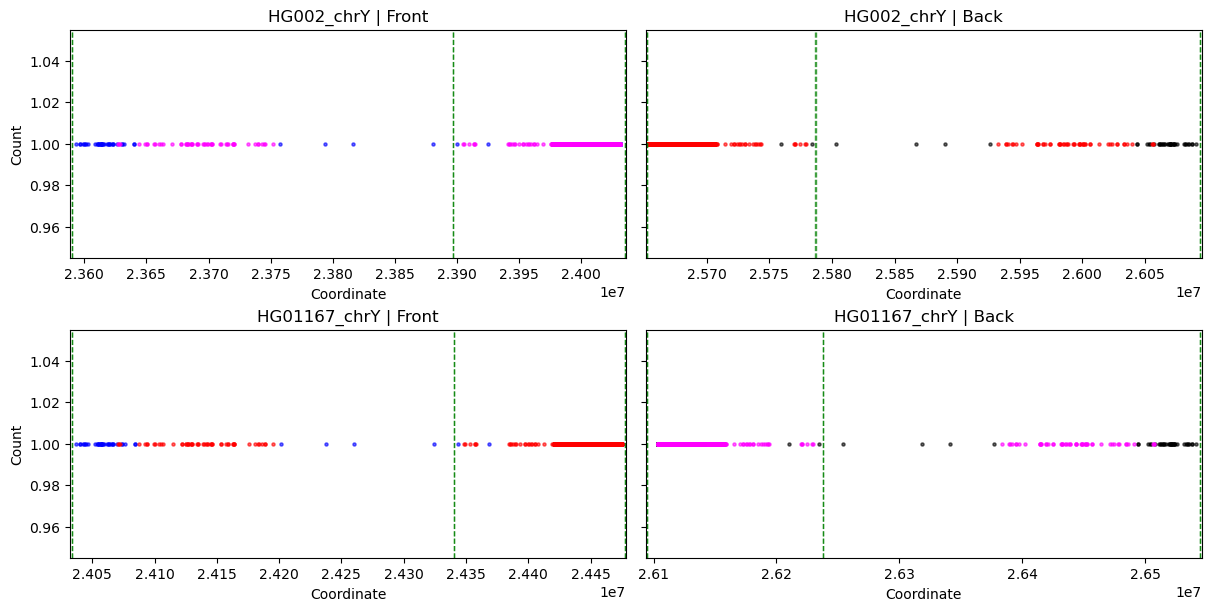

HG02083_HG02392_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


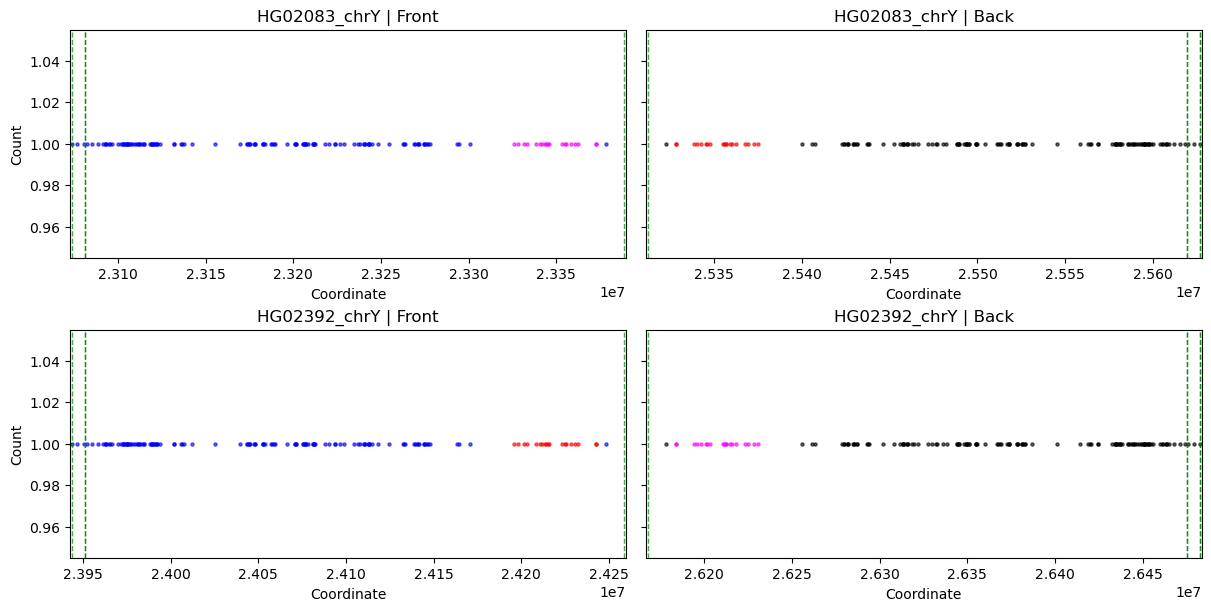

NA18620_HG02040_T2TvsGRCh38_REDObreakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


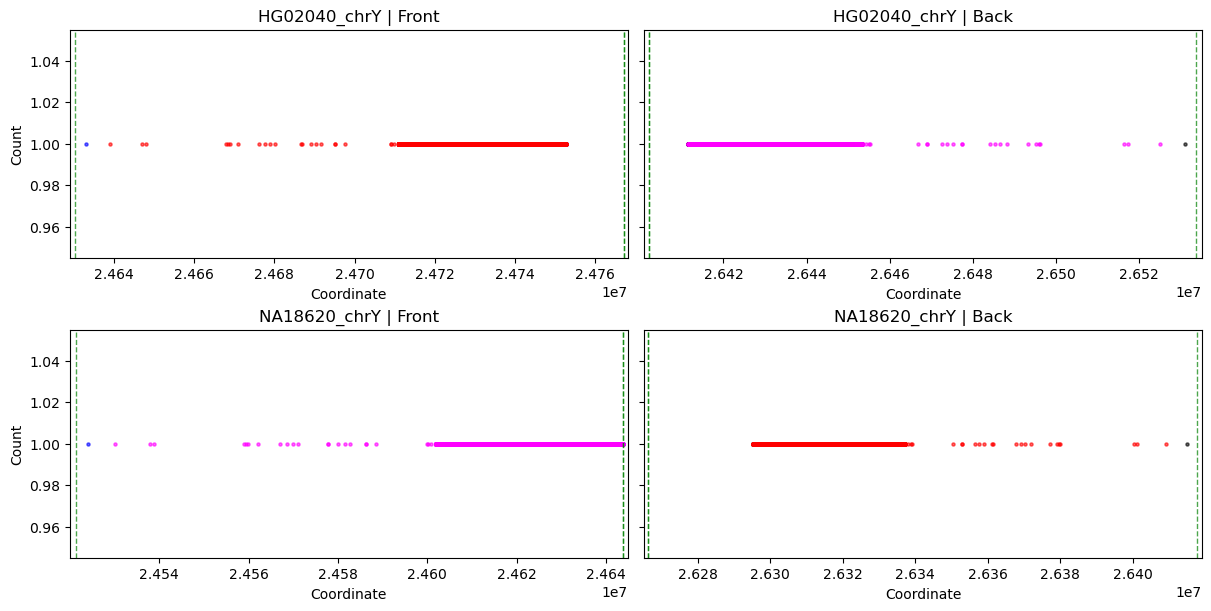

HG04199_HG01192_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


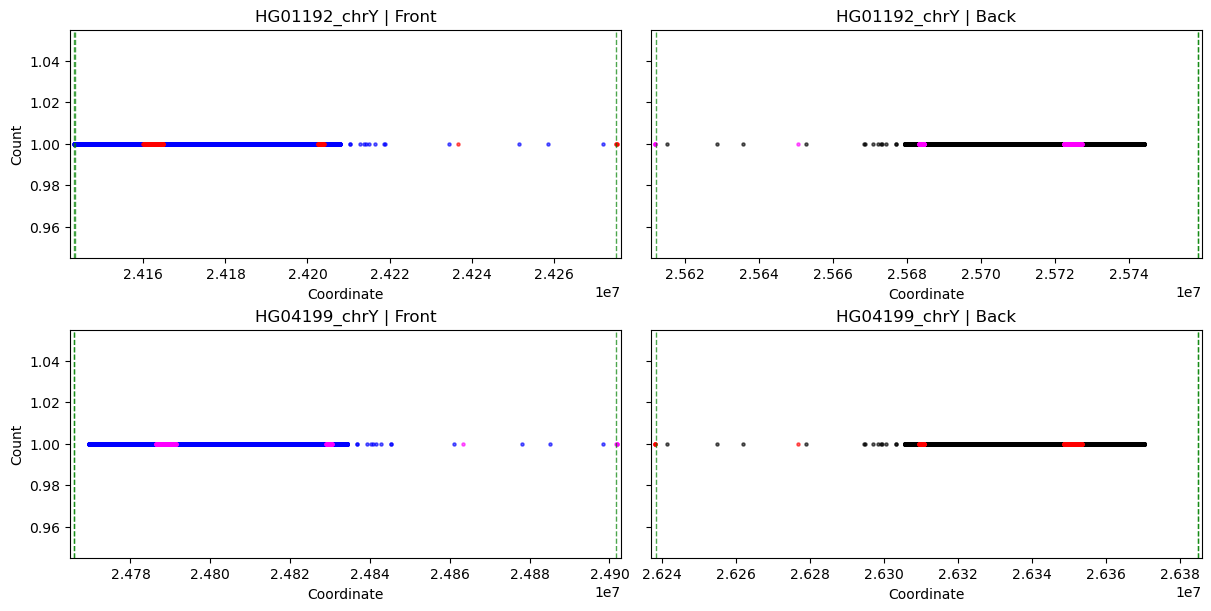

NA18620_NA19705_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


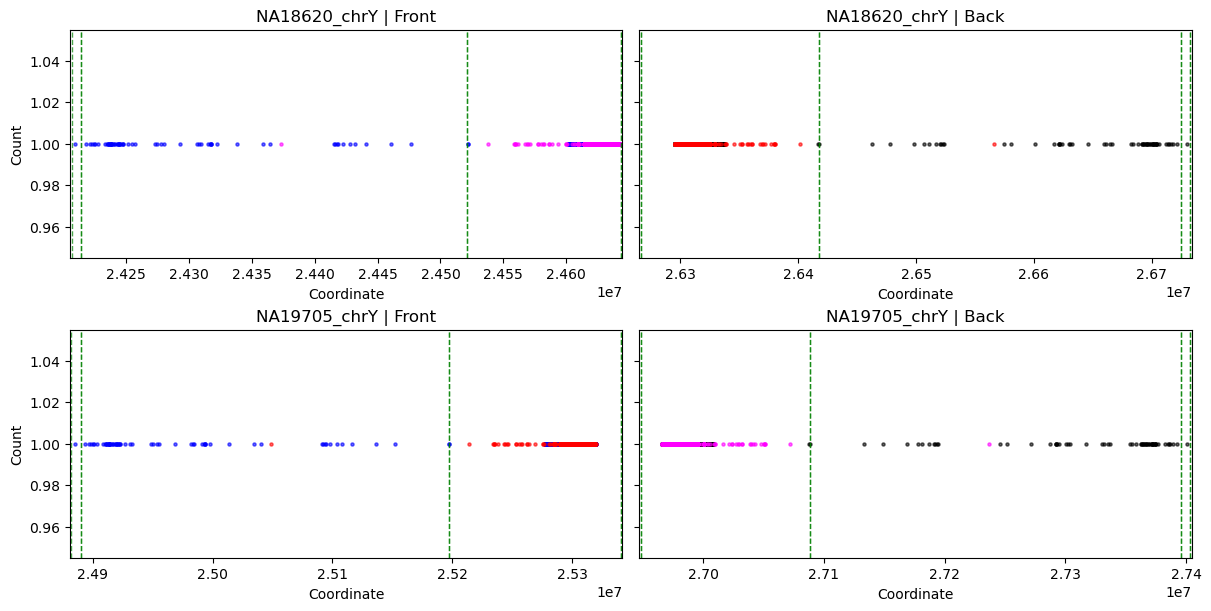

HG00642_200085_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


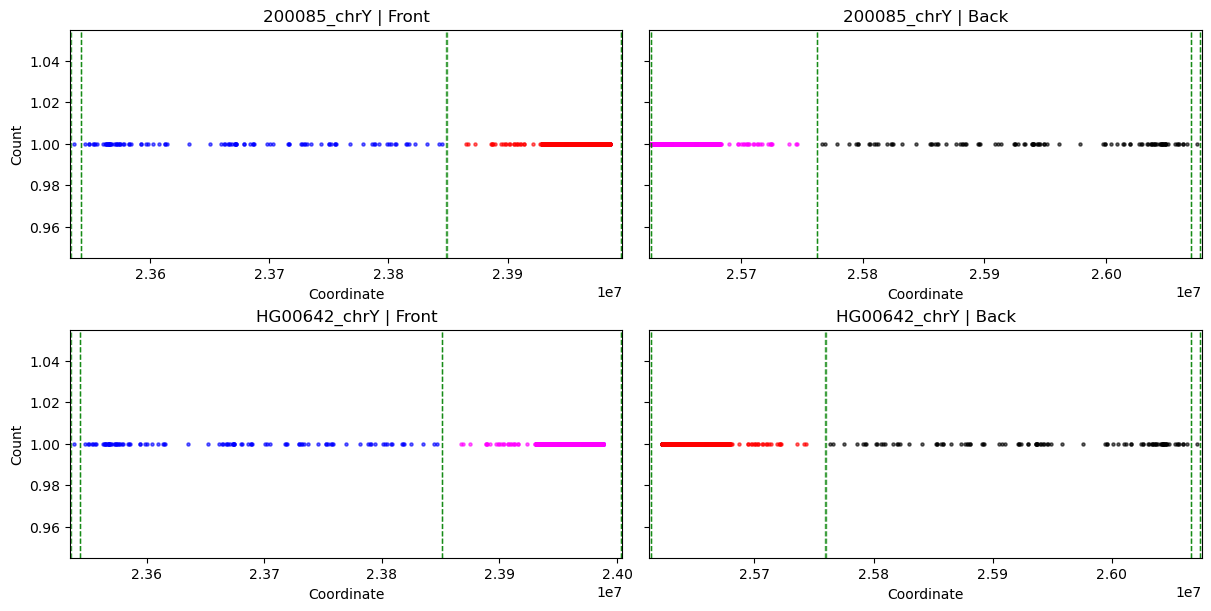

HG01952_HG01928_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


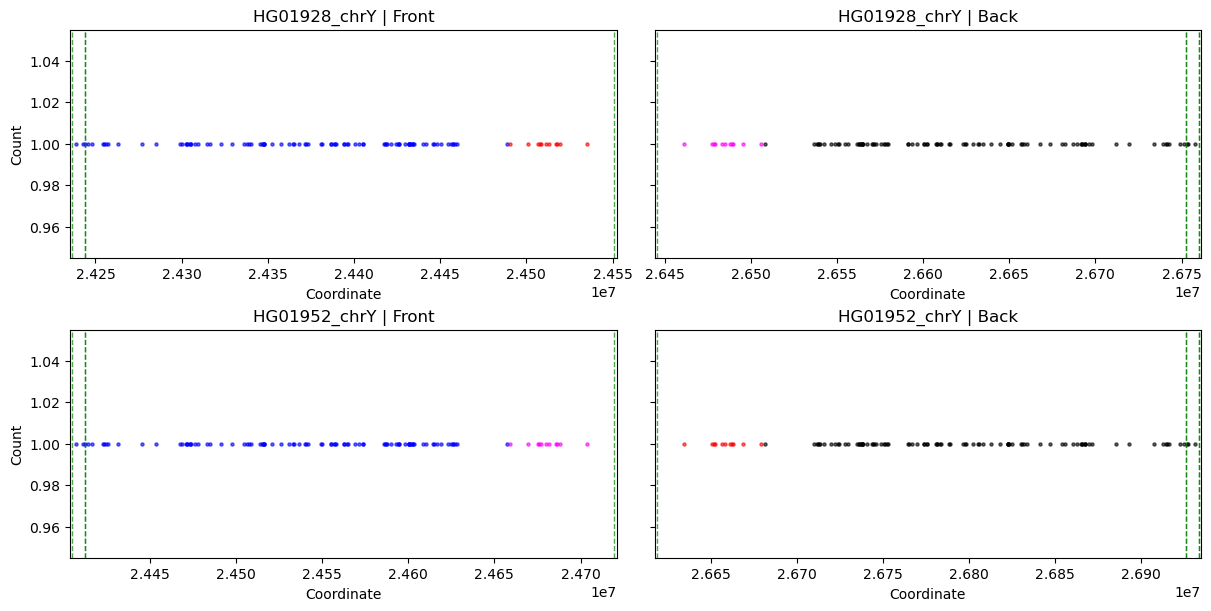

HG03688_HG01192_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


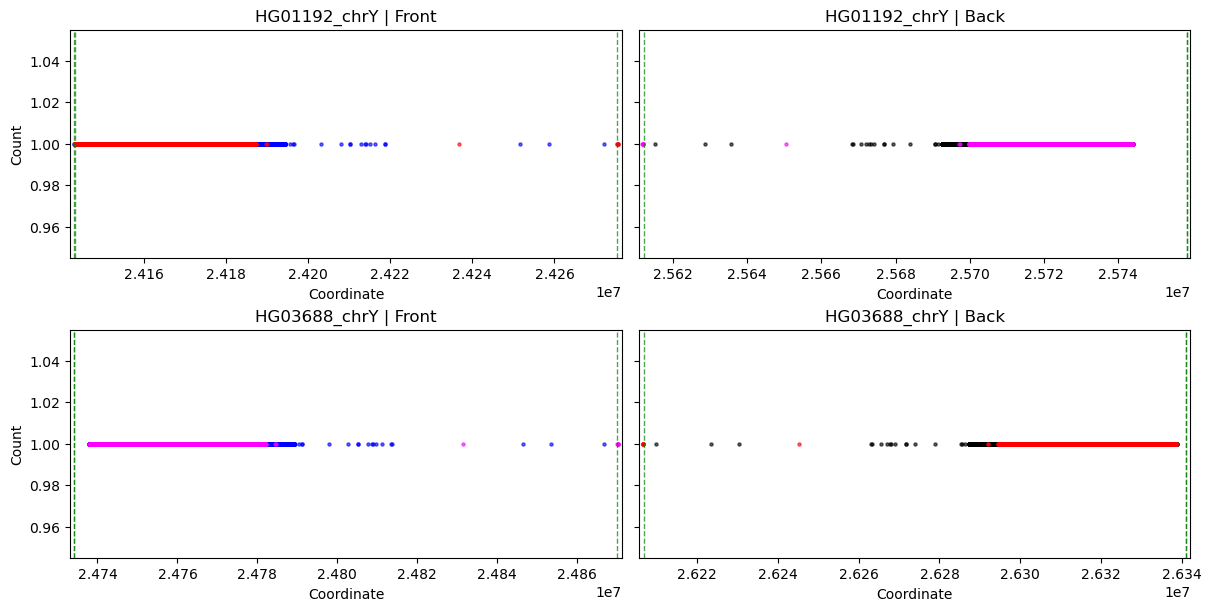

HG01258_HG01167_T2TvsGRCh38_Redbreakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


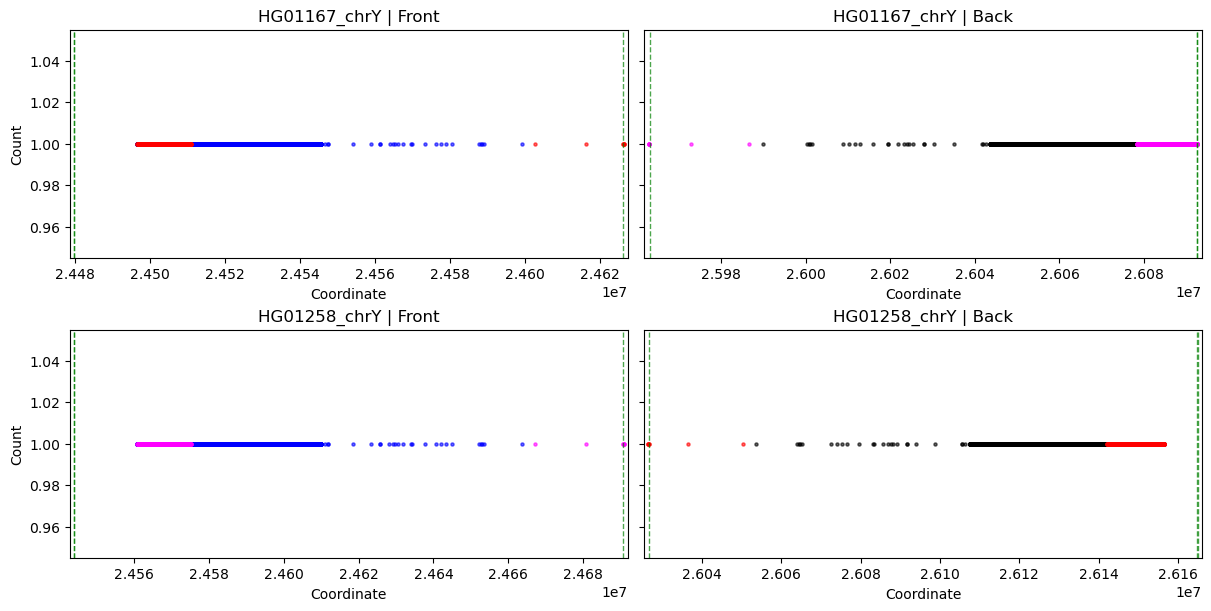

HG01255_HG01167_T2TvsGRCh38_Redbreakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


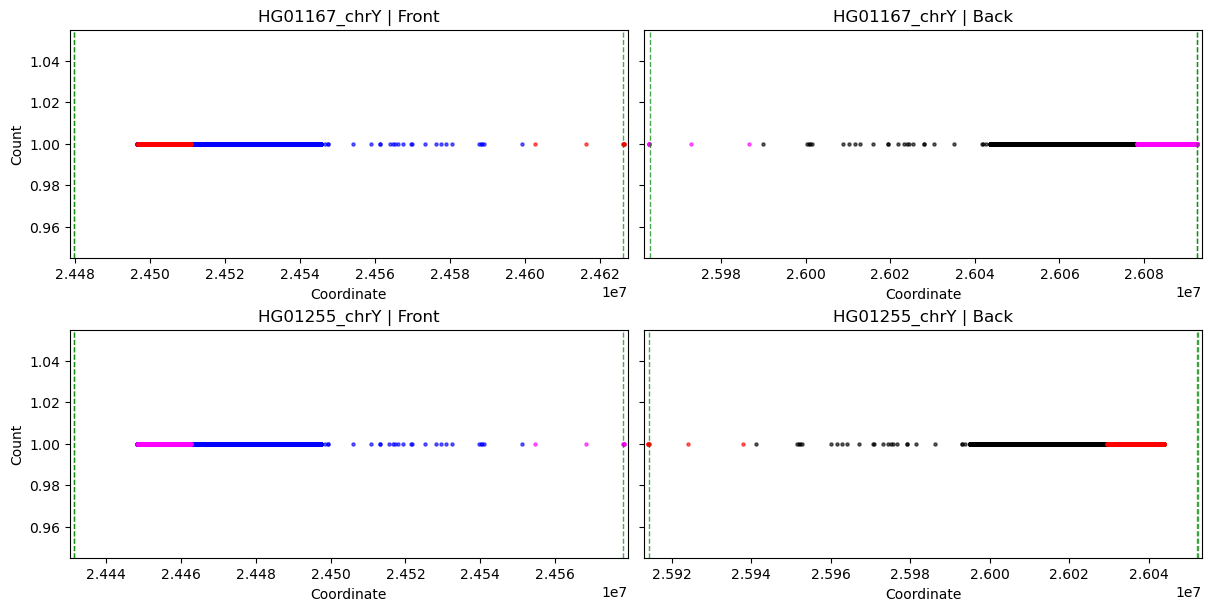

HG02514_HG02392_T2TvsGRCh38_breakpoint.fasta


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_8193/4271469154.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()


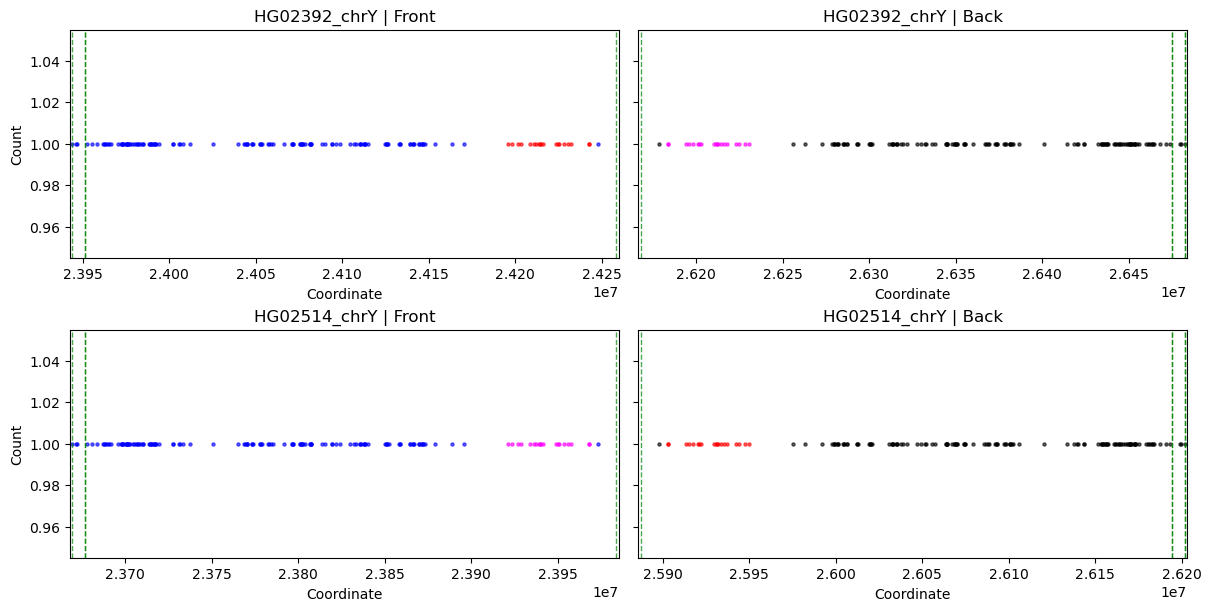

In [16]:
import numpy as np
import collections

directory='/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/alignments/done/'
for fastaFile in os.listdir(directory):
    if '.fasta' in fastaFile:
        print(fastaFile)

        try:
            outFilePath = '/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/T2TvsGRCh38_'+str(fastaFile.split(".fasta")[0])+".csv"
            df_wide = msa_fasta_to_df(directory+fastaFile)
            
            coordinateDict = {r: {} for r in df_wide.index}
            for r in df_wide.index:
                rlow = str(r).lower()
                region = r.split(":", 1)[1]
                a, b = region.split("-", 1)
                start_bp = int(a)
                end_bp   = int(b.split("_", 1)[0])  
            
                if "_front" in rlow:
                    coord = start_bp
                    step = 1
                elif "_back" in rlow:
                    coord = end_bp
                    step = -1
                else:
                    raise ValueError(f"Row missing _front/_back suffix: {r}")
            
                for c in df_wide.columns:
                    if df_wide.at[r, c] == "-":
                        continue
                    coordinateDict[r][c] = coord
                    coord += step
            
            df_wide2 = df_wide.replace("-",np.nan).dropna(axis=1).copy()
            interestingColumns=[]
            for column in df_wide2.columns:
                if len(set(df_wide2[column]))==1:
                    continue
                else:
                    interestingColumns.append(column)
    
            newDF = df_wide[interestingColumns].copy()
    
            pairs = pair_front_back_different_samples(list(newDF.index))
    
            newList=[]
            for column in newDF.columns:
                tempDict = collections.Counter(newDF[column])
                
                if len(tempDict)==2 and tempDict[list(tempDict.keys())[0]]==2:
                    
                    if newDF.at[pairs[0][0],column]==newDF.at[pairs[0][1],column]:
                        newList.append([pairs[0][0], coordinateDict[pairs[0][0]][column], 1, 'magenta', 'INV_SNP'])
                        newList.append([pairs[0][1], coordinateDict[pairs[0][1]][column], 1, 'magenta', 'INV_SNP'])
                        newList.append([pairs[1][0], coordinateDict[pairs[1][0]][column], 1, 'red', 'INV_SNP'])
                        newList.append([pairs[1][1], coordinateDict[pairs[1][1]][column], 1, 'red', 'INV_SNP'])
                    else:
                        newList.append([pairs[0][0], coordinateDict[pairs[0][0]][column], 1, 'blue', 'SHARED_SNP'])
                        newList.append([pairs[0][1], coordinateDict[pairs[0][1]][column], 1, 'black', 'SHARED_SNP'])
                        newList.append([pairs[1][0], coordinateDict[pairs[1][0]][column], 1, 'blue', 'SHARED_SNP'])
                        newList.append([pairs[1][1], coordinateDict[pairs[1][1]][column], 1, 'black', 'SHARED_SNP'])
    
            finalCountDF = pd.DataFrame(data=newList, columns=['Sample', 'Coordinate', 'Hit', 'MatchType', 'SNPtype'])
    
            testDF = finalCountDF.sort_values(by=['Sample','Coordinate']).copy()
            tempDFList=[]
            for sample in set(testDF['Sample']):
                tempDF = testDF[testDF['Sample']==sample].copy()
            
                sampleList=[]
                tempList=[]
                for row in tempDF.index:
                    coordinate = tempDF.at[row,'Coordinate']
                    if len(tempList) == 0:
                        tempList.append(coordinate)
                        snpType = tempDF.at[row,'SNPtype']
            
                    else:
                        if tempDF.at[row,'SNPtype'] == snpType:
                            tempList.append(coordinate)
                        else:
                            tempDFList.append([sample.split(":")[0].split("_")[0],sample.split("_")[-1], len(tempList),min(tempList), max(tempList), max(tempList)-min(tempList), snpType])
                            tempList = []
                            tempList.append(coordinate)
                            snpType = tempDF.at[row,'SNPtype']
            
                if len(tempList) >0:
                    tempDFList.append([sample.split(":")[0].split("_")[0],sample.split("_")[-1], len(tempList), min(tempList), max(tempList), max(tempList)-min(tempList),snpType])
    
            windowDF = pd.DataFrame(data=tempDFList, columns=['Sample','Side','SNPCount','Start','End','WindowSize','SNPtype'])  
            windowDF.sort_values(by=['Sample','Start'], inplace=True)
            windowDF2 = add_breakpoint_windows(windowDF)
            windowDF2['ColorBlocks']='TEMP'
            windowDF2['ColorBlock_Coord']='TEMP'
    
            vlines={}
            for sample in set(finalCountDF['Sample']):
                side = sample.split("_")[-1]
                contig = sample.split(":")[0]
                startcoord = int(sample.split(":")[1].split("-")[0])
                endcoord = int(sample.split(":")[1].split("-")[1].split("_")[0])
                
                df2 = df[(df['contig']==contig)].copy()
                goodRows=[]
                for row,start,end in zip(df2.index, df2['start'], df2['end']):
                    if start < endcoord and end > startcoord:
                        goodRows.append(row)
                df3 = df2.loc[goodRows].copy()
                coords=[x+1 for x in df3['start']]
                for y in df3['end']:
                    coords.append(y-1)
                vlines[(contig, side)]=sorted(coords)
                
    
    
            for sample in set(windowDF2['Sample']):
                windowDF3 = windowDF2[windowDF2['Sample'] == sample].copy()
                blockDF = df[df['contig'] == sample + "_chrY"].copy()
            
                for row in windowDF3.index:
                    start = int(windowDF3.at[row, 'Start'])
                    end   = int(windowDF3.at[row, 'End'])
                    side  = str(windowDF3.at[row, 'Side']).lower()
            
                    w_lo, w_hi = (start, end) if start <= end else (end, start)
            
                    temp_blocks = []
                    temp_coords = []  
            
                    for row2 in blockDF.index:
                        blockstart = int(blockDF.at[row2, 'start'])
                        blockend   = int(blockDF.at[row2, 'end'])
                        colorblock = str(blockDF.at[row2, 'colorblock'])
            
                        ov_lo = max(w_lo, blockstart)
                        ov_hi = min(w_hi, blockend)
            
                        if ov_lo <= ov_hi:
                            temp_blocks.append(colorblock)
            
                            if side == "front":
                                coord_info = {
                                    "into_at_start": ov_lo - blockstart,      
                                    "into_at_end":   ov_hi - blockstart,      
                                    "to_end_from_start": blockend - ov_lo,    
                                    "to_end_from_end":   blockend - ov_hi,    
                                }
                            else:  
                                coord_info = {
                                    "into_at_start": blockend - ov_hi,       
                                    "into_at_end":   blockend - ov_lo,        
                                    "to_start_from_start": ov_hi - blockstart,
                                    "to_start_from_end":   ov_lo - blockstart,
                                }
            
                            temp_coords.append(coord_info)
            
                    windowDF2.at[row, 'ColorBlocks'] = temp_blocks
                    windowDF2.at[row, 'ColorBlock_Coord'] = temp_coords

            windowDF2[(windowDF2['WindowSize']>=20)].to_csv(outFilePath)
            nearestWindows=[]
            for side in ['Front','Back']:
                for sample in set(windowDF2['Sample']):
                    tempTestDF = windowDF2[(windowDF2['Sample']==sample) & (windowDF2['Side']==side) & (windowDF2['SNPtype']=='INV_SNP')].copy()
                    tempTestDF.sort_values(by=['WindowSize'], inplace=True, ascending=False)
            
                    indexNumber = tempTestDF.iloc[0].name
                    if side == 'Back':
                        nearestWindows.append(indexNumber+1)
                    else:
                        nearestWindows.append(indexNumber-1)
                        
            bwinDF = windowDF2.loc[nearestWindows].copy()
            bwinDF['Designator']='LARGE_INV_SNP_WINDOW'
    
            endWindows=[]
            for side in ['Front','Back']:
                for sample in set(windowDF2['Sample']):
                    tempTestDF = windowDF2[(windowDF2['Sample']==sample) & (windowDF2['Side']==side) & (windowDF2['SNPtype']=='INV_SNP')].copy()
            
                    
                    if side == 'Back':
                        indexNumber = tempTestDF.iloc[0].name
                        endWindows.append(indexNumber+1)
                        
                    else:
                        indexNumber = tempTestDF.iloc[-1].name
                        endWindows.append(indexNumber-1)
    
            endwinDF = windowDF2.loc[endWindows].copy()
            endwinDF['Designator']='LAST_INV_SNP_WINDOW'
    
    
            winDFs = [bwinDF,endwinDF]
            finalWindowDF = pd.concat(winDFs)
            finalWindowDF.sort_values(by=['Sample','Start'], inplace=True)
            finalWindowDF.reset_index(inplace=True)
    
            finalWindowDF['Repeats']='NONE_FOUND'
            for sample in finalWindowDF["Sample"].unique():
                rmDF = pd.read_csv(rmDict[sample], sep="\t").copy()
            
                rmDF["query_match_start"] = pd.to_numeric(rmDF["query_match_start"], errors="coerce")
                rmDF["query_match_end"]   = pd.to_numeric(rmDF["query_match_end"], errors="coerce")
                rmDF = rmDF.dropna(subset=["query_match_start", "query_match_end"])
            
                tempWindows = finalWindowDF[finalWindowDF["Sample"] == sample].copy()
            
                for w_idx in tempWindows.index:
                    start = int(tempWindows.at[w_idx, "Start"])
                    end   = int(tempWindows.at[w_idx, "End"])
                    w_lo, w_hi = (start, end) if start <= end else (end, start)
            
                    mask = (rmDF["query_match_start"] <= w_hi) & (rmDF["query_match_end"] >= w_lo)
                    ov = rmDF.loc[mask].copy()
                    ov['Size']=ov['query_match_end']-ov['query_match_start']
            
                    tempHolder=[]
                    for repeat, orientation, size in zip(ov['repeat_motif_name'], ov['match_orientation'], ov['Size']):
                        tempHolder.append(str(repeat)+"~"+str(orientation)+"~"+str(size))
            
                    
                    finalWindowDF.at[w_idx,'Repeats']=tempHolder
    
            #finalWindowDF.to_csv(outFilePath)
            plot_front_back_quadrants(finalCountDF, vlines=vlines)
        except:
            print("FILE IS MESSED UP SOMEHOW")

## Read in the datframes you just made

In [19]:
df1 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG002_HG01167_T2TvsGRCh38_breakpoint.csv')
df2 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG01255_HG01167_T2TvsGRCh38_Redbreakpoint.csv')
df3 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG01258_HG01167_T2TvsGRCh38_Redbreakpoint.csv')
df4 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG01952_HG01928_T2TvsGRCh38_breakpoint.csv')
df5 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG02027_HG02392_T2TvsGRCh38_breakpoint.csv')
df6 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG02071_HG00706_T2TvsGRCh38_Redbreakpoint.csv')
df7 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG02083_HG02392_T2TvsGRCh38_breakpoint.csv')
df8 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG02492_HG01167_T2TvsGRCh38_breakpoint.csv')
df9 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG02514_HG02392_T2TvsGRCh38_breakpoint.csv')
df10 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG02717_HG03471_T2TvsGRCh38_breakpoint.csv')
df11 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG03688_HG01192_T2TvsGRCh38_breakpoint.csv')
df12 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG04199_HG01192_T2TvsGRCh38_breakpoint.csv')
df13 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_NA18620_HG02040_T2TvsGRCh38_REDObreakpoint.csv')
df14 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/dataframes/Finalized_Manually/T2TvsGRCh38_HG00642_200085_T2TvsGRCh38_breakpoint.csv')

In [20]:
myconcatList = [df1,df2,df3,df4,df5,df6,df7,df8,df9,df10,df11,df12,df13, df14]
concatDF = pd.concat(myconcatList).reset_index().drop(columns=['index','Unnamed: 0'])

In [21]:
samplesWithInversion=['HG002','HG01255','HG01258','HG01952','HG02027','HG00706','HG02083','HG02492','HG02514','HG03471',
                     'HG03688','HG04199','NA18620', 'HG00642']

In [22]:
frontDF = concatDF[(concatDF['Sample'].isin(samplesWithInversion)) & (concatDF['Side']=='Front')].copy()
backDF = concatDF[(concatDF['Sample'].isin(samplesWithInversion)) & (concatDF['Side']=='Back')].copy()

#These were done by hand due to the complexity of some samples
checkedFrontDF= frontDF.copy()
checkedbackDF = backDF.copy()

In [23]:
frontDF

,Sample,Side,SNPCount,Start,End,WindowSize,SNPtype,ColorBlocks,ColorBlock_Coord
0,HG002,Front,NaN,23899815,23904581,4766,BREAKPOINT_WINDOW,['red4'],"[{'into_at_start': 2706, 'into_at_end': 7472, ..."
6,HG01255,Front,NaN,24551071,24554504,3433,BREAKPOINT_WINDOW,['red1'],"[{'into_at_start': 119532, 'into_at_end': 1229..."
10,HG01258,Front,NaN,24663600,24667033,3433,BREAKPOINT_WINDOW,['red1'],"[{'into_at_start': 119528, 'into_at_end': 1229..."
14,HG01952,Front,NaN,24657189,24659323,2134,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 244674, 'into_at_end': 2468..."
16,HG02027,Front,NaN,23671687,23678262,6575,BREAKPOINT_WINDOW,['green3'],"[{'into_at_start': 3721, 'into_at_end': 10296,..."
20,HG00706,Front,NaN,24352617,24375791,23174,BREAKPOINT_WINDOW,['red3'],"[{'into_at_start': 17474, 'into_at_end': 40648..."
24,HG02083,Front,NaN,23300554,23326049,25495,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 219163, 'into_at_end': 2446..."
30,HG02492,Front,NaN,23510941,23516021,5080,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 96033, 'into_at_end': 10111..."
34,HG02514,Front,NaN,23896075,23921570,25495,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 219178, 'into_at_end': 2446..."
38,HG03471,Front,NaN,24632164,24650509,18345,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 208488, 'into_at_end': 2268..."


In [ ]:
#RED BLOCKS
RED1:
Orange: HG002, NA18620 2.7-7.5kb
yellow: HG00706 17474-40648 from start

RED2:
    blue: HG01255,HG01258 26904-23471kbp from end of red
    pink: HG03688,HG04199 3098-0 from end

#GREEN BLOCKS
black: HG01952,HG02083,HG02514 62474-60340 from end / 87959-62464 / 87958-62463
       HG03471 98597-80252
green: HG02492 96033-101113kb from start
purple: HG02027 3721-10296 from start


In [31]:
import ast
for row in checkedFrontDF.index:
    print(checkedFrontDF.at[row,'Sample'])
    print(checkedFrontDF.at[row,'ColorBlocks'])
    myListDict = ast.literal_eval(str(checkedFrontDF.at[row,'ColorBlock_Coord']))
    if len(myListDict)>1:
        myFirstKey = myListDict[0]
        mySecondKey = myListDict[1]
        print('From End: '+str(myFirstKey['to_end_from_start']))
        print('From Start: '+str(mySecondKey['into_at_end']))
    else:
        print('ONE')
        myFirstKey = myListDict[0]
        mySecondKey = myListDict[0]
        print('From Start: '+str(myFirstKey['into_at_start']))
        print('To End: '+str(mySecondKey['into_at_end']))
        print('to_end_from_start: '+str(myFirstKey['to_end_from_start']))
        print('to_end_from_end: '+str(mySecondKey['to_end_from_end']))

    print('\n')

HG002
['red4']
ONE
From Start: 2706
To End: 7472
to_end_from_start: 135324
to_end_from_end: 130558


HG01255
['red1']
ONE
From Start: 119532
To End: 122965
to_end_from_start: 26904
to_end_from_end: 23471


HG01258
['red1']
ONE
From Start: 119528
To End: 122961
to_end_from_start: 26904
to_end_from_end: 23471


HG01952
['green1']
ONE
From Start: 244674
To End: 246808
to_end_from_start: 62474
to_end_from_end: 60340


HG02027
['green3']
ONE
From Start: 3721
To End: 10296
to_end_from_start: 303413
to_end_from_end: 296838


HG00706
['red3']
ONE
From Start: 17474
To End: 40648
to_end_from_start: 114472
to_end_from_end: 91298


HG02083
['green1']
ONE
From Start: 219163
To End: 244658
to_end_from_start: 87959
to_end_from_end: 62464


HG02492
['green1']
ONE
From Start: 96033
To End: 101113
to_end_from_start: 211105
to_end_from_end: 206025


HG02514
['green1']
ONE
From Start: 219178
To End: 244673
to_end_from_start: 87958
to_end_from_end: 62463


HG03471
['green1']
ONE
From Start: 208488
To End: 

In [24]:
myNewConcatList = [checkedFrontDF,checkedbackDF]

In [25]:
finalWindowDF = pd.concat(myNewConcatList).reset_index().drop(columns=['index'])

In [26]:
finalWindowDF

,Sample,Side,SNPCount,Start,End,WindowSize,SNPtype,ColorBlocks,ColorBlock_Coord
0,HG002,Front,NaN,23899815,23904581,4766,BREAKPOINT_WINDOW,['red4'],"[{'into_at_start': 2706, 'into_at_end': 7472, ..."
1,HG01255,Front,NaN,24551071,24554504,3433,BREAKPOINT_WINDOW,['red1'],"[{'into_at_start': 119532, 'into_at_end': 1229..."
2,HG01258,Front,NaN,24663600,24667033,3433,BREAKPOINT_WINDOW,['red1'],"[{'into_at_start': 119528, 'into_at_end': 1229..."
3,HG01952,Front,NaN,24657189,24659323,2134,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 244674, 'into_at_end': 2468..."
4,HG02027,Front,NaN,23671687,23678262,6575,BREAKPOINT_WINDOW,['green3'],"[{'into_at_start': 3721, 'into_at_end': 10296,..."
5,HG00706,Front,NaN,24352617,24375791,23174,BREAKPOINT_WINDOW,['red3'],"[{'into_at_start': 17474, 'into_at_end': 40648..."
6,HG02083,Front,NaN,23300554,23326049,25495,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 219163, 'into_at_end': 2446..."
7,HG02492,Front,NaN,23510941,23516021,5080,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 96033, 'into_at_end': 10111..."
8,HG02514,Front,NaN,23896075,23921570,25495,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 219178, 'into_at_end': 2446..."
9,HG03471,Front,NaN,24632164,24650509,18345,BREAKPOINT_WINDOW,['green1'],"[{'into_at_start': 208488, 'into_at_end': 2268..."


In [27]:
finalWindowDF['Repeats']='NONE_FOUND'
for sample in finalWindowDF["Sample"].unique():
    rmDF = pd.read_csv(rmDict[sample], sep="\t").copy()

    rmDF["query_match_start"] = pd.to_numeric(rmDF["query_match_start"], errors="coerce")
    rmDF["query_match_end"]   = pd.to_numeric(rmDF["query_match_end"], errors="coerce")
    rmDF = rmDF.dropna(subset=["query_match_start", "query_match_end"])

    tempWindows = finalWindowDF[finalWindowDF["Sample"] == sample].copy()

    for w_idx in tempWindows.index:
        start = int(tempWindows.at[w_idx, "Start"])
        end   = int(tempWindows.at[w_idx, "End"])
        w_lo, w_hi = (start, end) if start <= end else (end, start)

        mask = (rmDF["query_match_start"] <= w_hi) & (rmDF["query_match_end"] >= w_lo)
        ov = rmDF.loc[mask].copy()
        ov['Size']=ov['query_match_end']-ov['query_match_start']

        tempHolder=[]
        for repeat, orientation, size in zip(ov['repeat_motif_name'], ov['match_orientation'], ov['Size']):
            tempHolder.append(str(repeat)+"~"+str(orientation)+"~"+str(size))

        
        finalWindowDF.at[w_idx,'Repeats']=tempHolder

In [28]:
#finalWindowDF.to_csv("/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/T2Tvshg38/grgr_FINAL_breakpointWindows.csv")

In [29]:
myFinalBWDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/Figures/Breakpoints/b2b3Inversion/b2b3_FINAL_breakpointWindows.csv")

In [30]:
myFinalBWDF['Inversion']='b2b3'
finalWindowDF['Inversion']='grgr'

In [31]:
finalConcatList = [myFinalBWDF,finalWindowDF]
pubSuppTableDF = pd.concat(finalConcatList).reset_index().drop(columns=['index','Unnamed: 0'])

In [35]:
pubSuppTableDF.at[37,'ColorBlock_Coord']

"[{'into_at_start': 0, 'into_at_end': 16502, 'to_start_from_start': 146487, 'to_start_from_end': 129985}, {'into_at_start': 303426, 'into_at_end': 307116, 'to_start_from_start': 3690, 'to_start_from_end': 0}]"

In [33]:
#pubSuppTableDF[[x for x in pubSuppTableDF.columns if 'Designator' != x]].set_index('Sample').to_csv("/AZFc_Inversion_BreakpointWindows_05012026.csv")